# Baseline 3: Train from scratch - No Attention

In [1]:
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**Bước 1: Khai báo Thư viện và Thiết lập Hệ thống**

Giải thích:

- Nạp các thư viện cốt lõi như torch, torchvision, numpy và công cụ vẽ biểu đồ matplotlib.

- Khởi tạo bộ sinh số ngẫu nhiên (seed) để đảm bảo kết quả huấn luyện mang tính lặp lại (reproducible) ở các lần chạy khác nhau.

- Kiểm tra và kích hoạt GPU nếu thiết bị có hỗ trợ.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import random
from collections import Counter
from PIL import Image

# Cố định Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


**Bước 2: Tải Dữ liệu Ảnh**

Giải thích:

- Tải bộ ảnh MS COCO Val 2014 trực tiếp về môi trường máy chủ để đảm bảo tốc độ đọc file nhanh nhất.

- Giải nén thư mục chứa ảnh vào vị trí quy định.

- Lưu ý: Cần đảm bảo file JSON VQA-E_val_set.json đã được upload sẵn vào thư mục Annotations.

In [3]:
# Tạo thư mục chứa dữ liệu
os.makedirs('/content/VQA_E/Images', exist_ok=True)
os.makedirs('/content/VQA_E/Annotations', exist_ok=True)

print("1. Đang tải Ảnh COCO Val 2014 (~6GB)...")
!wget -c -q http://images.cocodataset.org/zips/val2014.zip -P /content/VQA_E/Images/

print("2. Đang giải nén dữ liệu...")
!unzip -q -n /content/VQA_E/Images/val2014.zip -d /content/VQA_E/Images/

print("Hoàn tất tải và giải nén!")
# Đừng quên upload VQA-E_val_set.json vào /content/VQA_E/Annotations/

1. Đang tải Ảnh COCO Val 2014 (~6GB)...
2. Đang giải nén dữ liệu...
Hoàn tất tải và giải nén!


**Bước 3: Khai phá và Đồng bộ Dữ liệu (Data Parsing)** 

Giải thích:

- Đọc dữ liệu từ file JSON, liên kết ID ảnh với đường dẫn file .jpg trên ổ cứng.

- Xáo trộn ngẫu nhiên dữ liệu và chia thành 2 tập: Train (huấn luyện) và Val (kiểm định).

In [9]:
def load_vqa_e_data(json_path, img_dir, max_samples=15000):
    print("Đang đọc file JSON VQA-E...")
    with open(json_path, 'r') as f:
        data = json.load(f)

    dataset = []
    for item in data:
        img_id = item['img_id']
        img_filename = f"COCO_val2014_{img_id:012d}.jpg"

        dataset.append({
            'image_path': os.path.join(img_dir, "val2014", img_filename),
            'question': item['question'],
            'explanation': item['explanation'][0] # Lấy câu giải thích đầu tiên
        })

    random.shuffle(dataset)
    if max_samples:
        dataset = dataset[:max_samples]
    return dataset

JSON_PATH = '/content/VQA_E/Annotations/VQA-E_val_set.json'
IMG_DIR = '/content/VQA_E/Images'

# Giả sử file JSON đã được upload
all_data = load_vqa_e_data(JSON_PATH, IMG_DIR, max_samples=10000)

split_idx = int(len(all_data) * 0.8)
train_data = all_data[:split_idx]
val_data = all_data[split_idx:]
print(f"Số lượng Train: {len(train_data)} | Val: {len(val_data)}")

Đang đọc file JSON VQA-E...
Số lượng Train: 8000 | Val: 2000


**Bước 4: Xây dựng Từ điển (Vocabulary)**

Giải thích:

- Do không dùng từ điển có sẵn (như GloVe hay Word2Vec), chúng ta phải tự xây dựng bộ từ vựng từ tập dữ liệu huấn luyện.

- Chuẩn hóa văn bản, thêm các token đặc biệt: <pad> (đệm độ dài chuỗi), <sos> (bắt đầu chuỗi), <eos> (kết thúc chuỗi) và <unk> (từ chưa biết).

In [10]:
import re

class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        # Biến chữ thường và loại bỏ ký tự đặc biệt
        text = text.lower()
        return re.findall(r'\b\w+\b', text)

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenize(text)
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<unk>"]
            for token in tokenized_text
        ]

# Gom toàn bộ text (câu hỏi + giải thích) để xây từ điển
all_texts = [d['question'] for d in train_data] + [d['explanation'] for d in train_data]
vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(all_texts)
print(f"Kích thước từ điển tự xây dựng: {len(vocab)} từ")

Kích thước từ điển tự xây dựng: 2829 từ


**Bước 5: Định nghĩa Custom Dataset và DataLoader**

Giải thích:

- Lớp VQAEDataset chịu trách nhiệm nạp ảnh, thực hiện biến đổi ảnh cơ bản (resize, normalize) và chuyển hóa văn bản thành mảng các số nguyên (ID từ vựng).

- Hàm collate_fn giúp đệm chuỗi (<pad>) để các câu trong cùng một mẻ (batch) có chiều dài bằng nhau.

In [11]:
class VQAEDataset(Dataset):
    def __init__(self, data, vocab, transform=None):
        self.data = data
        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        item = self.data[index]
        img = Image.open(item['image_path']).convert("RGB")

        if self.transform:
            img = self.transform(img)

        # Numericalize Câu hỏi
        q_tokens = [self.vocab.stoi["<sos>"]] + self.vocab.numericalize(item['question']) + [self.vocab.stoi["<eos>"]]
        # Numericalize Lời giải thích
        e_tokens = [self.vocab.stoi["<sos>"]] + self.vocab.numericalize(item['explanation']) + [self.vocab.stoi["<eos>"]]

        return img, torch.tensor(q_tokens), torch.tensor(e_tokens)

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)

        questions = [item[1] for item in batch]
        questions = pad_sequence(questions, batch_first=True, padding_value=self.pad_idx)

        explanations = [item[2] for item in batch]
        explanations = pad_sequence(explanations, batch_first=True, padding_value=self.pad_idx)

        return imgs, questions, explanations

# Pipeline chuẩn hóa ảnh không pre-train
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = VQAEDataset(train_data, vocab, transform)
val_dataset = VQAEDataset(val_data, vocab, transform)

pad_idx = vocab.stoi["<pad>"]
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=MyCollate(pad_idx))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=MyCollate(pad_idx))

**Bước 6: Xây dựng Kiến trúc Mô hình (Từ đầu, Không Attention)**

Giải thích:

- Image Encoder (CustomCNN): Tự định nghĩa một mạng ConvNet đơn giản đi kèm AdaptiveAvgPool2d((1,1)) để dồn toàn bộ đặc trưng không gian về một vector đơn nhất.

- Question Encoder: Sử dụng mạng BiLSTM.

- Decoder: Mạng LSTM đơn hướng, sinh từng từ dựa trên hidden state được cấp (kết hợp từ Ảnh và Câu hỏi).

In [12]:
class CustomCNN(nn.Module):
    def __init__(self, embed_size=512):
        super(CustomCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)) # Bỏ đặc trưng không gian (No Attention)
        )
        self.fc = nn.Linear(256, embed_size)

    def forward(self, images):
        x = self.cnn(images)         # [B, 256, 1, 1]
        x = x.view(x.size(0), -1)    # Flatten -> [B, 256]
        return self.fc(x)            # [B, embed_size]

class VQAE_NoAttention_Scratch(nn.Module):
    def __init__(self, vocab_size, img_embed=512, q_embed=256, q_hidden=256, dec_hidden=512):
        super(VQAE_NoAttention_Scratch, self).__init__()

        self.vocab_size = vocab_size
        self.img_encoder = CustomCNN(embed_size=img_embed)

        # Word Embedding học từ đầu
        self.embedding = nn.Embedding(vocab_size, q_embed)
        self.q_lstm = nn.LSTM(q_embed, q_hidden, batch_first=True, bidirectional=True)

        # Lớp nén: Ảnh (512) + Text (2 * 256) -> Decoder hidden (512)
        self.fusion_h = nn.Linear(img_embed + q_hidden*2, dec_hidden)
        self.fusion_c = nn.Linear(img_embed + q_hidden*2, dec_hidden)

        self.dec_lstm = nn.LSTM(q_embed, dec_hidden, batch_first=True)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)

    def forward(self, images, questions, explanations, teacher_forcing_ratio=0.5):
        batch_size = images.size(0)
        seq_len = explanations.size(1)

        # 1. Xử lý Ảnh
        img_features = self.img_encoder(images) # [B, 512]

        # 2. Xử lý Câu hỏi
        q_embedded = self.embedding(questions)
        _, (q_h, q_c) = self.q_lstm(q_embedded)
        q_features = torch.cat((q_h[0], q_h[1]), dim=1) # [B, 512]

        # 3. Kết hợp để khởi tạo trạng thái cho Decoder
        combined = torch.cat((img_features, q_features), dim=1) # [B, 1024]
        hidden = self.fusion_h(combined).unsqueeze(0)           # [1, B, 512]
        cell = self.fusion_c(combined).unsqueeze(0)             # [1, B, 512]

        # 4. Giải mã sinh từ (Decoding)
        outputs = torch.zeros(batch_size, seq_len, self.vocab_size).to(images.device)
        x = explanations[:, 0].unsqueeze(1) # Bắt đầu bằng <sos>

        for t in range(1, seq_len):
            embedded = self.embedding(x)
            out, (hidden, cell) = self.dec_lstm(embedded, (hidden, cell))
            prediction = self.fc_out(out.squeeze(1))

            outputs[:, t, :] = prediction

            best_guess = prediction.argmax(1)
            # Teacher forcing
            if random.random() < teacher_forcing_ratio:
                x = explanations[:, t].unsqueeze(1)
            else:
                x = best_guess.unsqueeze(1)

        return outputs

**Bước 7: Kiểm tra thử Dữ liệu (Sanity Check)**

Giải thích:

- Bước này lấy ngẫu nhiên một mẻ (batch) từ train_loader để in ra kích thước (shape) của ma trận ảnh, câu hỏi và nhãn.

- Việc này giúp đảm bảo DataLoader và collate_fn hoạt động đúng, đệm (padding) chuẩn. Đồng thời, hàm decode_tokens sẽ dịch ngược các con số (ID) về lại text để bạn xem mắt thường mô hình thực sự đang "đọc" gì.

--- KIỂM TRA KÍCH THƯỚC TENSOR ---
Shape của Images: torch.Size([32, 3, 224, 224]) -> [Batch, Channels, Height, Width]
Shape của Questions: torch.Size([32, 10]) -> [Batch, Max_Seq_Len]
Shape của Explanations: torch.Size([32, 25]) -> [Batch, Max_Seq_Len]
------------------------------


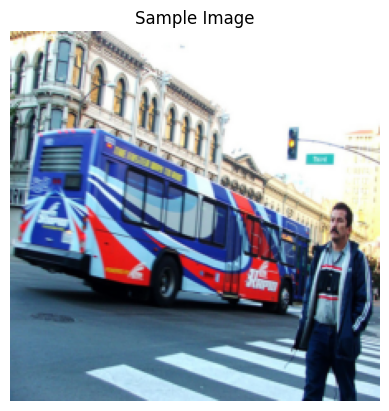

Câu hỏi (gốc): what does it say on back of bus
Giải thích (gốc): a red white and blue rapid bus crossing the intersection


In [13]:
import matplotlib.pyplot as plt

def decode_tokens(tokens, vocab):
    """Dịch ngược list các token ID thành câu văn, bỏ qua các thẻ đặc biệt"""
    words = []
    for t in tokens:
        word = vocab.itos[t.item()]
        if word not in ["<pad>", "<sos>", "<eos>"]:
            words.append(word)
    return " ".join(words)

# Lấy thử 1 batch từ tập Train
sample_imgs, sample_qs, sample_exps = next(iter(train_loader))

print("--- KIỂM TRA KÍCH THƯỚC TENSOR ---")
print(f"Shape của Images: {sample_imgs.shape} -> [Batch, Channels, Height, Width]")
print(f"Shape của Questions: {sample_qs.shape} -> [Batch, Max_Seq_Len]")
print(f"Shape của Explanations: {sample_exps.shape} -> [Batch, Max_Seq_Len]")
print("-" * 30)

# Hiển thị mẫu đầu tiên trong batch
sample_idx = 0
img_to_show = sample_imgs[sample_idx]

# Denormalize ảnh từ [-1, 1] về [0, 1] để hiển thị
img_to_show = img_to_show / 2 + 0.5
img_to_show = img_to_show.numpy().transpose(1, 2, 0)

plt.imshow(img_to_show)
plt.axis('off')
plt.title("Sample Image")
plt.show()

# In text tương ứng
print("Câu hỏi (gốc):", decode_tokens(sample_qs[sample_idx], vocab))
print("Giải thích (gốc):", decode_tokens(sample_exps[sample_idx], vocab))

**Bước 8: Khai báo Hàm Huấn luyện và Đánh giá**

Giải thích:

- Hàm train_epoch: Thực hiện quá trình học, lan truyền xuôi, tính lỗi CrossEntropyLoss (đã bỏ qua padding token), cập nhật trọng số gradient.

- Hàm val_epoch: Kiểm tra mô hình trên tập Validation (không dùng teacher forcing). Hàm cung cấp Loss và Accuracy (tỉ lệ đoán đúng từng từ).

In [14]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for imgs, questions, exps in dataloader:
        imgs, questions, exps = imgs.to(device), questions.to(device), exps.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, questions, exps, teacher_forcing_ratio=0.5)

        # Định dạng lại Tensor để tính Loss, bỏ qua cột số 0 (<sos>)
        outputs = outputs[:, 1:].reshape(-1, outputs.shape[-1])
        targets = exps[:, 1:].reshape(-1)

        loss = criterion(outputs, targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

def val_epoch(model, dataloader, criterion, device, pad_idx):
    model.eval()
    total_loss = 0
    correct = 0
    total_words = 0

    with torch.no_grad():
        for imgs, questions, exps in dataloader:
            imgs, questions, exps = imgs.to(device), questions.to(device), exps.to(device)

            outputs = model(imgs, questions, exps, teacher_forcing_ratio=0.0)

            outputs_flat = outputs[:, 1:].reshape(-1, outputs.shape[-1])
            targets_flat = exps[:, 1:].reshape(-1)

            loss = criterion(outputs_flat, targets_flat)
            total_loss += loss.item()

            # Tính accuracy (bỏ qua những từ là padding)
            predictions = outputs_flat.argmax(1)
            mask = (targets_flat != pad_idx)
            correct += (predictions[mask] == targets_flat[mask]).sum().item()
            total_words += mask.sum().item()

    return total_loss / len(dataloader), (correct / total_words) * 100

**Bước 9: Khởi tạo Mô hình và Thực thi Huấn luyện**

Giải thích:

- Thiết lập số lượng Epochs. Khởi tạo mạng Adam làm bộ tối ưu hóa hóa.

- Lưu lại lịch sử Training Loss, Validation Loss và Validation Accuracy để trực quan hóa ở bước sau.

In [21]:
model = VQAE_NoAttention_Scratch(vocab_size=len(vocab)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<pad>"])

EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("Bắt đầu huấn luyện mô hình (From Scratch - No Attention)...")
for epoch in range(EPOCHS):
    t_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    v_loss, v_acc = val_epoch(model, val_loader, criterion, device, vocab.stoi["<pad>"])

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}%")

Bắt đầu huấn luyện mô hình (From Scratch - No Attention)...
Epoch 1/15 | Train Loss: 5.4468 | Val Loss: 4.8824 | Val Acc: 18.99%
Epoch 2/15 | Train Loss: 4.7779 | Val Loss: 4.8527 | Val Acc: 18.86%
Epoch 3/15 | Train Loss: 4.6650 | Val Loss: 4.8163 | Val Acc: 19.13%
Epoch 4/15 | Train Loss: 4.5791 | Val Loss: 4.8119 | Val Acc: 18.99%
Epoch 5/15 | Train Loss: 4.5194 | Val Loss: 4.8106 | Val Acc: 19.23%
Epoch 6/15 | Train Loss: 4.4565 | Val Loss: 4.7983 | Val Acc: 19.25%
Epoch 7/15 | Train Loss: 4.4170 | Val Loss: 4.8006 | Val Acc: 19.12%
Epoch 8/15 | Train Loss: 4.3688 | Val Loss: 4.8022 | Val Acc: 19.26%
Epoch 9/15 | Train Loss: 4.3239 | Val Loss: 4.7965 | Val Acc: 19.36%
Epoch 10/15 | Train Loss: 4.2931 | Val Loss: 4.8178 | Val Acc: 18.68%
Epoch 11/15 | Train Loss: 4.2271 | Val Loss: 4.7977 | Val Acc: 19.03%
Epoch 12/15 | Train Loss: 4.2112 | Val Loss: 4.8447 | Val Acc: 17.89%
Epoch 13/15 | Train Loss: 4.1736 | Val Loss: 4.7957 | Val Acc: 18.69%
Epoch 14/15 | Train Loss: 4.1209 | Val 

**Bước 9: Trực quan hóa Lịch sử Huấn luyện (Learning Curves)**

Giải thích:

- Vẽ biểu đồ để theo dõi xu hướng hội tụ của mô hình.

- Lưu ý: Do mô hình tự xây từ đầu và không có cơ chế Attention, điểm Accuracy trên tập Val thường sẽ khá thấp và Loss sẽ có xu hướng hội tụ chậm.

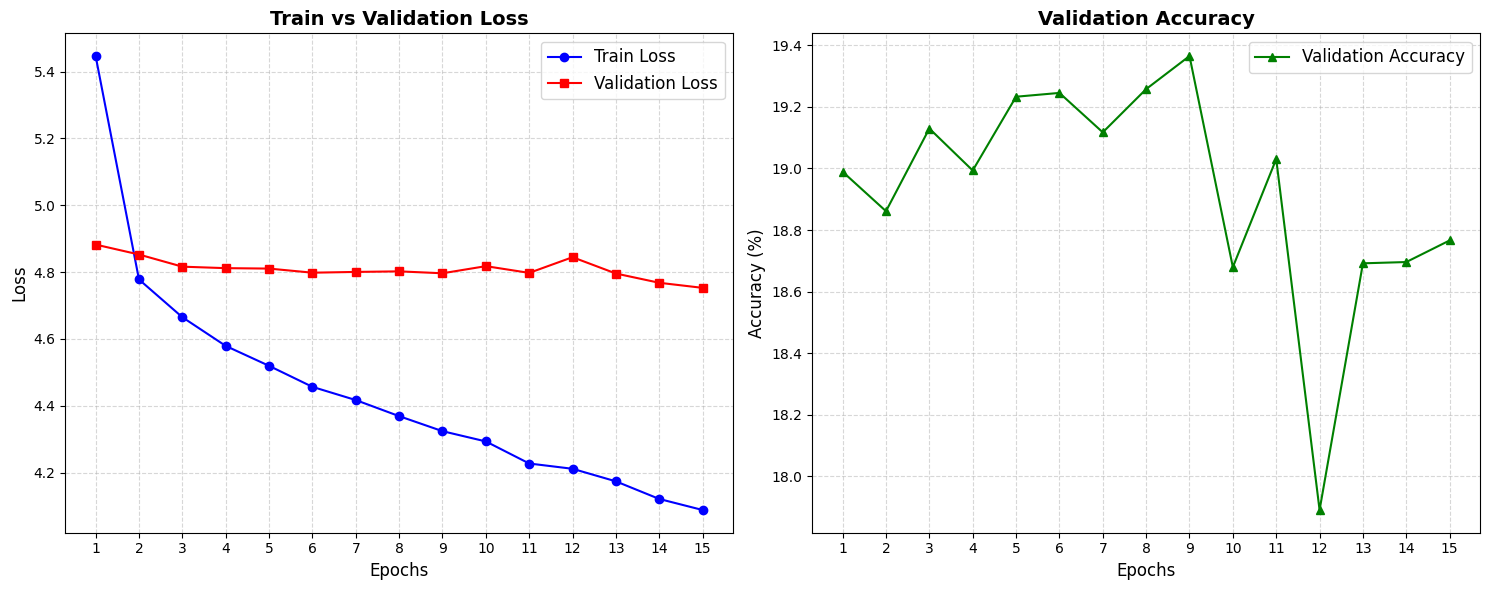

In [22]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(15, 6))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', marker='s')
plt.title('Train vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_acc'], 'g-', label='Validation Accuracy', marker='^')
plt.title('Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Bước 10: Thử nghiệm thực tế (Inference)**

Giải thích:

- Viết một hàm predict_vqa hoạt động độc lập không cần nhãn (explanations).

- Hàm này sẽ tự động mã hóa (encode) ảnh và câu hỏi mới để tạo ra trạng thái ẩn (hidden, cell). Sau đó, Decoder sẽ tự động sinh từng từ một thông qua vòng lặp (Greedy Search) cho đến khi gặp thẻ <eos> hoặc vượt quá độ dài cho phép.

ĐANG DỰ ĐOÁN...


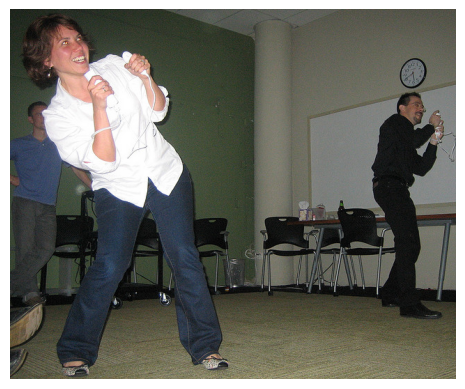

Câu hỏi của bạn: Are these people looking up?
Mô hình trả lời/giải thích: two people are standing in the grass
Ground Truth (Nhãn gốc): A man and woman are standing up in a classroom, playing the wii.


In [23]:
def predict_vqa(model, image_path, question, vocab, transform, device, max_len=20):
    model.eval() # Chuyển mô hình sang chế độ đánh giá

    # 1. Đọc và tiền xử lý ảnh
    img = Image.open(image_path).convert("RGB")
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_tensor = transform(img).unsqueeze(0).to(device) # Thêm batch dimension

    # 2. Tiền xử lý câu hỏi
    q_tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(question) + [vocab.stoi["<eos>"]]
    q_tensor = torch.tensor(q_tokens).unsqueeze(0).to(device)

    with torch.no_grad():
        # --- BƯỚC ENCODE ---
        img_features = model.img_encoder(img_tensor)

        q_embedded = model.embedding(q_tensor)
        _, (q_h, q_c) = model.q_lstm(q_embedded)
        q_features = torch.cat((q_h[0], q_h[1]), dim=1)

        # Trộn đặc trưng khởi tạo Decoder
        combined = torch.cat((img_features, q_features), dim=1)
        hidden = model.fusion_h(combined).unsqueeze(0)
        cell = model.fusion_c(combined).unsqueeze(0)

        # --- BƯỚC DECODE (Greedy Search) ---
        generated_words = []
        # Từ đầu tiên luôn là <sos>
        current_word = torch.tensor([[vocab.stoi["<sos>"]]]).to(device)

        for _ in range(max_len):
            embedded = model.embedding(current_word)
            out, (hidden, cell) = model.dec_lstm(embedded, (hidden, cell))
            prediction = model.fc_out(out.squeeze(1))

            # Lấy từ có xác suất cao nhất
            pred_token = prediction.argmax(1).item()

            # Dừng nếu gặp thẻ kết thúc
            if pred_token == vocab.stoi["<eos>"]:
                break

            generated_words.append(vocab.itos[pred_token])

            # Lấy từ vừa dự đoán làm đầu vào cho bước tiếp theo
            current_word = torch.tensor([[pred_token]]).to(device)

    print(f"Câu hỏi của bạn: {question}")
    print(f"Mô hình trả lời/giải thích: {' '.join(generated_words)}")

# --- TEST THỬ ---
# Lấy ngẫu nhiên 1 ảnh trong tập Val để test
sample_test = val_data[5] # Thay đổi index để test các ảnh khác
test_img_path = sample_test['image_path']
test_question = sample_test['question']

print("ĐANG DỰ ĐOÁN...")
predict_vqa(model, test_img_path, test_question, vocab, transform, device)
print(f"Ground Truth (Nhãn gốc): {sample_test['explanation']}")

In [18]:
# Cài đặt các thư viện hỗ trợ tính toán BLEU, ROUGE và CIDEr
!pip install nltk rouge-score pycocoevalcap

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=05ef485ef9b9834b8e41b782b5028b1e16f6a126e00032930dc030ed506c91a4
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [24]:
import torch
from tqdm import tqdm
from PIL import Image

# Import các hàm đánh giá từ pycocoevalcap (Cần chạy cell cài đặt pip trước đó)
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def evaluate_vqa_e(model, data, vocab, transform, device, max_len=20, num_samples=None):
    model.eval() # Chuyển mô hình sang chế độ Evaluation

    gts = {} # Ground truths
    res = {} # Predictions

    # Nếu num_samples được chỉ định, chỉ đánh giá trên một tập con (vd 200 mẫu) để test code trước
    eval_data = data[:num_samples] if num_samples else data

    print(f"Đang tiến hành dự đoán trên {len(eval_data)} mẫu...")

    with torch.no_grad():
        for idx, sample in enumerate(tqdm(eval_data, desc="Predicting")):
            img_path = sample['image_path']
            question = sample['question']
            gt_explanation = sample['explanation'] # Câu giải thích gốc (Ground truth)

            # 1. Tiền xử lý ảnh
            img = Image.open(img_path).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)

            # 2. Tiền xử lý câu hỏi
            q_tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(question) + [vocab.stoi["<eos>"]]
            q_tensor = torch.tensor(q_tokens).unsqueeze(0).to(device)

            # 3. Encode (Trích xuất đặc trưng)
            img_features = model.img_encoder(img_tensor)
            q_embedded = model.embedding(q_tensor)
            _, (q_h, q_c) = model.q_lstm(q_embedded)
            q_features = torch.cat((q_h[0], q_h[1]), dim=1)

            combined = torch.cat((img_features, q_features), dim=1)
            hidden = model.fusion_h(combined).unsqueeze(0)
            cell = model.fusion_c(combined).unsqueeze(0)

            # 4. Decode (Tạo câu giải thích bằng Greedy Search)
            generated_words = []
            current_word = torch.tensor([[vocab.stoi["<sos>"]]]).to(device)

            for _ in range(max_len):
                embedded = model.embedding(current_word)
                out, (hidden, cell) = model.dec_lstm(embedded, (hidden, cell))
                prediction = model.fc_out(out.squeeze(1))

                pred_token = prediction.argmax(1).item()
                if pred_token == vocab.stoi["<eos>"]:
                    break

                generated_words.append(vocab.itos[pred_token])
                current_word = torch.tensor([[pred_token]]).to(device)

            pred_explanation = " ".join(generated_words)

            # Cần lưu vào dictionary với value là 1 mảng các câu string theo chuẩn của pycocoevalcap
            gts[str(idx)] = [gt_explanation]
            res[str(idx)] = [pred_explanation]

    # Khởi tạo các module tính toán metrics
    print("\nĐang tính toán các độ đo (Metrics)...")
    scorers = [
        (Bleu(4), ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]),
        (Rouge(), "ROUGE-L"),
        (Cider(), "CIDEr")
    ]

    results = {}
    for scorer, method in scorers:
        score, _ = scorer.compute_score(gts, res)
        if type(method) == list:
            for m, s in zip(method, score):
                results[m] = s
                print(f"{m}: {s:.4f}")
        else:
            results[method] = score
            print(f"{method}: {score:.4f}")

    return results

# GỌI HÀM ĐÁNH GIÁ (Trên tập val_data)
print("=== BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH VQA-E ===")

# Lưu ý: Hiện tại đang set num_samples=200 để chạy nhanh.
# Nếu bạn muốn đánh giá TRÊN TOÀN BỘ TẬP VALIDATION, hãy đổi num_samples=None
metrics_results = evaluate_vqa_e(
    model=model,
    data=val_data,
    vocab=vocab,
    transform=transform,
    device=device,
    num_samples=200
)

=== BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH VQA-E ===
Đang tiến hành dự đoán trên 200 mẫu...


Predicting: 100%|██████████| 200/200 [00:02<00:00, 74.46it/s]



Đang tính toán các độ đo (Metrics)...
{'testlen': 1747, 'reflen': 2225, 'guess': [1747, 1547, 1347, 1147], 'correct': [460, 74, 7, 1]}
ratio: 0.7851685393254898
BLEU-1: 0.2003
BLEU-2: 0.0854
BLEU-3: 0.0307
BLEU-4: 0.0118
ROUGE-L: 0.2020
CIDEr: 0.1747
